<a href="https://colab.research.google.com/github/ABBuriro/WideConvNet/blob/main/Results_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Paper: WideConvNet: Wide Convolutional Neural Network applied to ERP-based Classification of Alcoholics


**Statistical Test**
1. Wilcoxon signed-rank single sided test
2. Effect size, cofidence interval
3. Power analysis


**Interpretability using SHAP (SHapley Additive exPlanations)**
1. Correlation between SHAP values and prediction probabilities
2. One SHAP heat map per correctly predicted target class to get local insights
3. Mean of SHAP values across folds and time samples to understand global patterns for both alcoholic and control classes   
---

By: Dr. Abdul Baseer Buriro  
email: abdul.baseer@iba-suk.edu.pk  
December 23, 2024

In [ ]:
from IPython.display import clear_output
clear_output()
# Importing required libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
from scipy import stats
from scipy.stats import wilcoxon, rankdata, norm
from statsmodels.stats.power import TTestPower
import shap # may be used for plotting

In [ ]:
# Mounting Google Drive to get data
from google.colab import drive
drive.mount('/content/drive') #force_remount=False)
folder = '/content/drive/My Drive/Alcoholic_EEG_Research_Papers/Subjectwise_data/'
path = folder+'customAct/'
# ------------------------------------------------------------------------------
clear_output()

* <font color='blue'> training performances across folds and repetitions.

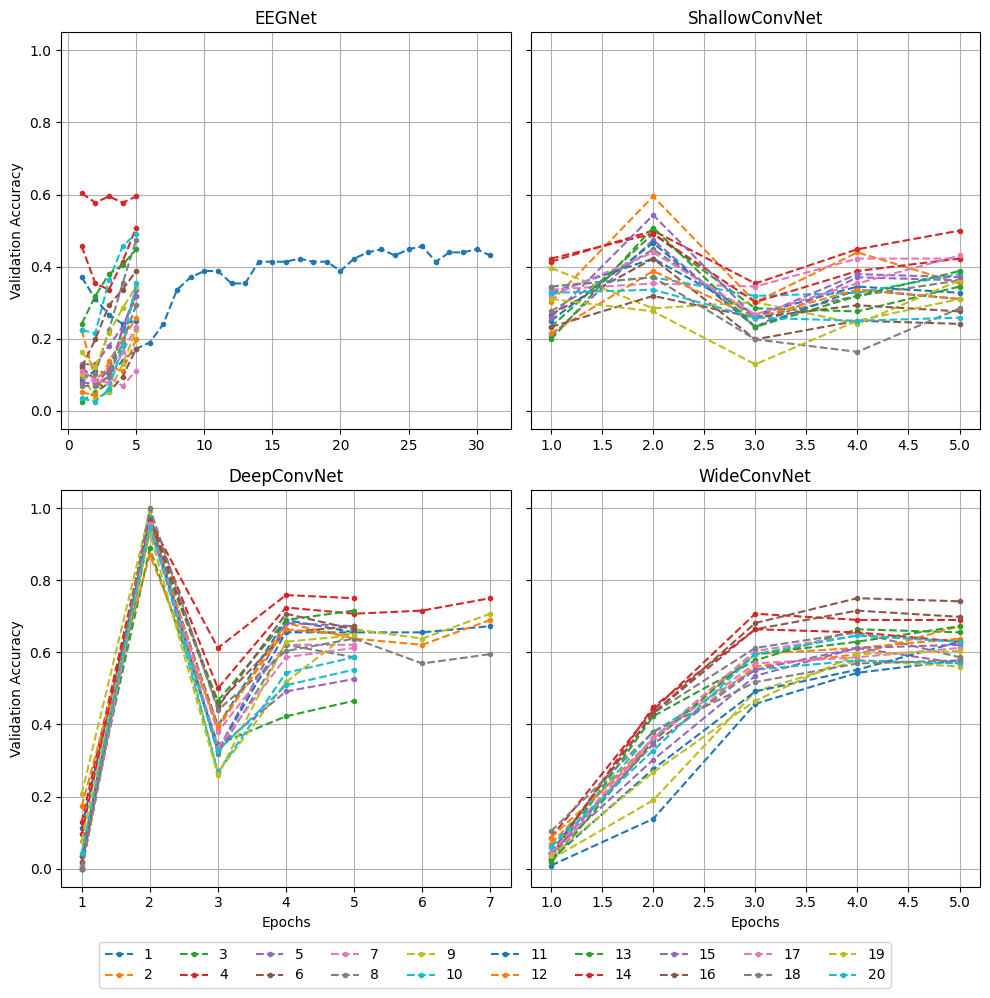

In [ ]:
Wide = np.load(path+'Models/Wide_histories.npy', allow_pickle=True)
Deep = np.load(path+'Models/Deep_histories.npy', allow_pickle=True)
Shal = np.load(path+'Models/Shallow_histories.npy', allow_pickle=True)
EEGN = np.load(path+'Models/EEGNet_histories.npy', allow_pickle=True)

lg = list(map(str,list(range(1,21))))

fig, axs = plt.subplots(2, 2, figsize=(10,10), sharey=True)
for i in range(0,20):
  Y = EEGN[i]['val_accuracy']
  X = range(1, len(Y)+1)
  axs[0, 0].plot(X,Y,'.--')
  #
  Y = Shal[i]['val_accuracy']
  X = range(1, len(Y)+1)
  axs[0, 1].plot(X,Y,'.--')
  #
  Y = Deep[i]['val_accuracy']
  X = range(1, len(Y)+1)
  axs[1, 0].plot(X,Y,'.--')
  #
  Y = Wide[i]['val_accuracy']
  X = range(1, len(Y)+1)
  axs[1, 1].plot(X,Y,'.--')
Title = ['EEGNet','ShallowConvNet','DeepConvNet','WideConvNet']
i = 0
for ax in axs.flat:
    ax.grid(True)
    ax.set_title(Title[i])
    i += 1
axs[0,0].set_ylabel('Validation Accuracy')
axs[1,0].set_ylabel('Validation Accuracy')
axs[1,0].set_xlabel('Epochs')
axs[1,1].set_xlabel('Epochs')
fig.legend(lg,
           bbox_to_anchor=(0.5, -0.05),
           loc='lower center',
           ncol=10,
           fontsize=10)
#
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(path +'train.png', bbox_inches = 'tight')    # Save as PNG

plt.show()

* <font color='blue'>statistical tests and metrics.

In [ ]:
perf_wide = pd.read_csv(path+'Perf_Wide.csv')
perf_deep = pd.read_csv(path+'Perf_Deep.csv')
perf_shallow = pd.read_csv(path+'Perf_Shallow.csv')
perf_eegnet = pd.read_csv(path+'Perf_EEGNet.csv')

Acc_Wide, AUC_Wide = perf_wide['accuracy'], perf_wide['AUCROC']
Acc_Deep, AUC_Deep = perf_deep['accuracy'], perf_deep['AUCROC']
Acc_Shallow, AUC_Shallow = perf_shallow['accuracy'], perf_shallow['AUCROC']
Acc_EEGNet, AUC_EEGNet = perf_eegnet['accuracy'], perf_eegnet['AUCROC']

In [ ]:

# Function to compute key statistics of confidence interval, p-value,
# effect size, and power
def Key_Stats(Wide, Other):

  paired_diff = Wide - Other
  n_bootstrap = 1000
  bootstrap_diffs = []

  for _ in range(n_bootstrap):
    sample = np.random.choice(paired_diff, size=len(paired_diff), replace=True)
    bootstrap_diffs.append(np.mean(sample))

  bootstrap_diffs = np.array(bootstrap_diffs)
  ci_lower, ci_upper = np.percentile(bootstrap_diffs, [2.5, 97.5])
  stat, p_value = wilcoxon(paired_diff, alternative='greater')

  # Compute Cliff's delta
  delta = (np.sum(paired_diff > 0) - np.sum(paired_diff<0)) / len(paired_diff)

  # Results
  return stat, p_value, ci_lower, ci_upper, delta

In [ ]:
# Accuracy and AUCROC of WideConvNet vs DeepConvNet
stat_acc, p_acc, ci_acc, CI_acc, delta_acc = Key_Stats(Acc_Wide, Acc_Deep)
stat_auc, p_auc, ci_auc, CI_auc, delta_auc = Key_Stats(AUC_Wide, AUC_Deep)
print(f"stat={stat_acc:.3f},p={p_acc:.3f},ci={ci_acc:.3f},CI={CI_acc:.3f},delta={delta_acc:.3f}")
print(f"stat={stat_auc:.3f},p={p_auc:.3f},ci={ci_auc:.3f},CI={CI_auc:.3f},delta={delta_auc:.3f}")

stat=109.000,p=0.286,ci=-0.024,CI=0.044,delta=-0.050
stat=109.500,p=0.449,ci=-0.029,CI=0.036,delta=0.000


In [ ]:
# Accuracy and AUCROC of WideConvNet vs ShallowConvNet
stat_acc, p_acc, ci_acc, CI_acc, delta_acc = Key_Stats(Acc_Wide,Acc_Shallow)
stat_auc, p_auc, ci_auc, CI_auc, delta_auc = Key_Stats(AUC_Wide,AUC_Shallow)
print(f"stat={stat_acc:.3f},p={p_acc:.5f},ci={ci_acc:.3f},CI={CI_acc:.3f},delta={delta_acc:.3f}")
print(f"stat={stat_auc:.3f},p={p_auc:.5f},ci={ci_auc:.3f},CI={CI_auc:.3f},delta={delta_auc:.3f}")

stat=191.000,p=0.00029,ci=0.073,CI=0.191,delta=0.500
stat=196.000,p=0.00010,ci=0.100,CI=0.221,delta=0.600


In [ ]:
# Accuracy and AUCROC of WideConvNet vs EEGNet
stat_acc, p_acc, ci_acc, CI_acc, delta_acc = Key_Stats(Acc_Wide,Acc_EEGNet)
stat_auc, p_auc, ci_auc, CI_auc, delta_auc = Key_Stats(AUC_Wide,AUC_EEGNet)
print(f"stat={stat_acc:.3f},p={p_acc:.5f},ci={ci_acc:.3f},CI={CI_acc:.3f},delta={delta_acc:.3f}")
print(f"stat={stat_auc:.3f},p={p_auc:.5f},ci={ci_auc:.3f},CI={CI_auc:.3f},delta={delta_auc:.3f}")

stat=192.500,p=0.00024,ci=0.077,CI=0.190,delta=0.600
stat=201.000,p=0.00003,ci=0.113,CI=0.220,delta=0.700


In [ ]:
# power analysis for accuracies
pa = TTestPower()
# WideConvNet and EEGNet
print(f"Wide vs EEGNet Accuracy: {pa.power(effect_size=0.6,nobs=20,alpha=0.05)}")
# WideConvNet and ShallowConvNet
print(f"Wide vs Shallow Accuracy: {pa.power(effect_size=0.5,nobs=20,alpha=0.05)}")
# WideConvNet and DeepConvNet
print(f"Wide vs Deep Accuracy: {pa.power(effect_size=-0.05,nobs=20,alpha=0.05)}")


# power analysis for AUC-ROC
pa = TTestPower()
# WideConvNet and EEGNet
print(f"Wide vs EEGNet AUCROC: {pa.power(effect_size=0.7,nobs=20,alpha=0.05)}")
# WideConvNet and ShallowConvNet
print(f"Wide vs Shallow AUCROC: {pa.power(effect_size=0.6,nobs=20,alpha=0.05)}")
# WideConvNet and DeepConvNet
print(f"Wide vs Deep AUCROC: {pa.power(effect_size=0.0,nobs=20,alpha=0.05)}")

Wide vs EEGNet Accuracy: 0.7210050918002736
Wide vs Shallow Accuracy: 0.5645044105495046
Wide vs Deep Accuracy: 0.055190669457196875
Wide vs EEGNet AUCROC: 0.8435058663152307
Wide vs Shallow AUCROC: 0.7210050918002736
Wide vs Deep AUCROC: 0.050000000000004555


* <font color='blue'>SHAP values for WideConvNet and DeepConvNet.

In [ ]:
chan = ["FP1","FP2","F7","F8","F3","F4","C3","C4","P3","P4","O1","O2","T7","T8","P7","P8"]

In [ ]:
# SHAP Values for one 10-fold cross validations
shap_wide=np.load(path+'shap_wide.npy', allow_pickle=True)[640:,:,:,:]
shap_deep=np.load(path+'shap_deep.npy', allow_pickle=True)[640:,:,:,:,:]

# Prediction probabilities/scores of one 10-fold cross validation
sc_wide=np.load(path+'sc_wide.npy', allow_pickle=True)[10:,:,:]
sc_deep=np.load(path+'sc_deep.npy', allow_pickle=True)[10:,:,:]

In [ ]:
shap_deep=shap_deep.squeeze(axis=3)
shap_deep.shape

(640, 256, 16, 2)

In [ ]:
sc_wide.shape

(10, 64, 2)

In [ ]:
prob_wide = sc_wide.reshape(640,2)
ch_shap_wide = np.mean(shap_wide,axis=1)

prob_deep = sc_deep.reshape(640,2)
ch_shap_deep = np.mean(shap_deep,axis=1)



*   <font color='blue'> To determine the features on which a model relies



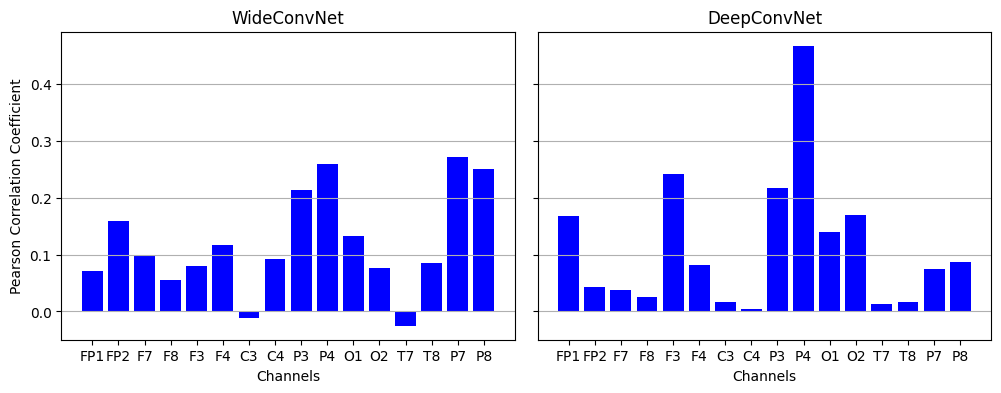

In [ ]:
corr_a_wide= np.zeros((16,1))
corr_a_deep= np.zeros((16,1))
for i in range(16):
  corr_a_wide[i] = np.corrcoef(prob_wide[:,0],ch_shap_wide[:,i,0])[0,1]
  corr_a_deep[i] = np.corrcoef(prob_deep[:,0],ch_shap_deep[:,i,0])[0,1]
fig, ax = plt.subplots(1,2,sharey=True,figsize=(12,4))
ax[0].bar(chan,corr_a_wide.reshape(16,),color='blue');
ax[0].set_ylabel("Pearson Correlation Coefficient");
ax[0].set_title("WideConvNet");
ax[0].set_xlabel("Channels");
ax[0].grid(axis='y')
ax[1].bar(chan,corr_a_deep.reshape(16,),color='blue');
ax[1].set_title("DeepConvNet");
ax[1].set_xlabel("Channels");
ax[1].grid(axis='y')
plt.subplots_adjust(hspace=0.3, wspace=0.05)

* <font color='blue'> To determine the local pattern, where the model has correctly predicted the target class.

In [ ]:
# NOTE: This will not run as true labels were not saved
last_fold_prob = prob_wide[-64:,:];
last_fold_label = Lab_ts
predicted_labels = np.argmax(last_fold_prob, axis=1)  # Predicted labels
true_labels_indices = np.argmax(last_fold_label, axis=1)  # True labels as indices

# Identify correctly classified instances
correct_indices = np.where(predicted_labels == true_labels_indices)[0]

# Extract probabilities of correctly classified instances
correct_probs = last_fold_prob[correct_indices, true_labels_indices[correct_indices]]

# Separate probabilities by class
alcoholic = correct_probs[true_labels_indices[correct_indices] == 0]
control = correct_probs[true_labels_indices[correct_indices] == 1]

# Separate probabilities for correctly classified instances by class
alcoholic = correct_probs[true_labels_indices[correct_indices] == 0]
control = correct_probs[true_labels_indices[correct_indices] == 1]

# Separate original indices of correctly classified instances by class
alcoholic_indices = correct_indices[true_labels_indices[correct_indices] == 0]
control_indices = correct_indices[true_labels_indices[correct_indices] == 1]

# Find the maximum confidence for each class
if alcoholic.size > 0:
    max_conf_alcoholic = np.round(float(np.max(alcoholic)), 2)
    max_conf_alcoholic_index = alcoholic_indices[np.argmax(alcoholic)]
else:
    max_conf_alcoholic = None
    max_conf_alcoholic_index = None

if control.size > 0:
    max_conf_control = round(float(np.max(control)), 2)
    max_conf_control_index = control_indices[np.argmax(control)]
else:
    max_conf_control = None
    max_conf_control_index = None

print(f"Highest confidence for alcoholic: {max_conf_alcoholic}, Index: {max_conf_alcoholic_index}")
print(f"Highest confidence for control: {max_conf_control}, Index: {max_conf_control_index}")


Highest confidence for alcoholic: 0.99, Index: 49
Highest confidence for control: 0.98, Index: 4


<ipython-input-120-d76999370787>:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1]);


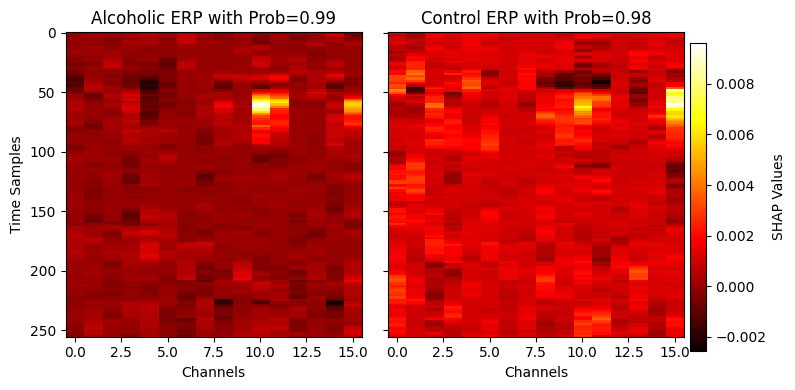

In [ ]:
alcoholic_shap = shap_wide[576+max_conf_alcoholic_index,:,:,0]
control_shap = shap_wide[576+max_conf_control_index,:,:,1]
fig, ax = plt.subplots(1,2,sharey=True,figsize=(8,4))
im = ax[0].imshow(alcoholic_shap, cmap='hot', interpolation='nearest', aspect='auto')
ax[0].set_title(f"Alcoholic ERP with Prob={max_conf_alcoholic}")
ax[0].set_ylabel("Time Samples")
ax[0].set_xlabel("Channels")
im1 = ax[1].imshow(control_shap,
                  cmap='hot',
                  interpolation='nearest',
                  aspect='auto')
ax[1].set_title(f"Control ERP with Prob={max_conf_control}")
ax[1].set_xlabel("Channels")

cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.04, pad=0.05)
cbar.set_label("SHAP Values")
plt.tight_layout(rect=[0, 0, 0.88, 1]);
plt.show();

#

* <font color='blue'> To determine the overall (global) pattern, SHAP values were averaged over all folds and trials

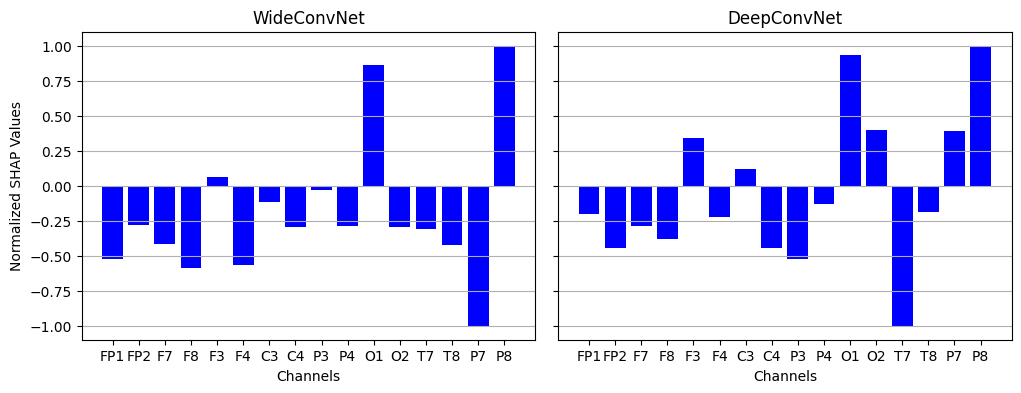

In [ ]:
over_al_wide = np.mean(np.mean(shap_wide[:,:,:,0],axis=0),axis=0)
norm_wide = 2*(over_al_wide - np.min(over_al_wide)) / (np.max(over_al_wide) - np.min(over_al_wide)) -1

over_al_deep = np.mean(np.mean(shap_deep[:,:,:,0],axis=0),axis=0)
norm_deep = 2*(over_al_deep - np.min(over_al_deep)) / (np.max(over_al_deep) - np.min(over_al_deep)) -1

fig, ax = plt.subplots(1,2,sharey=True,figsize=(12,4))
ax[0].bar(chan,norm_wide, color='blue');
ax[0].set_ylabel("Normalized SHAP Values");
ax[0].set_title("WideConvNet");
ax[0].set_xlabel("Channels");
ax[0].grid(axis='y')
ax[1].bar(chan,norm_deep, color='blue');
ax[1].set_title("DeepConvNet");
ax[1].set_xlabel("Channels");
ax[1].grid(axis='y')
plt.subplots_adjust(hspace=0.3, wspace=0.05)


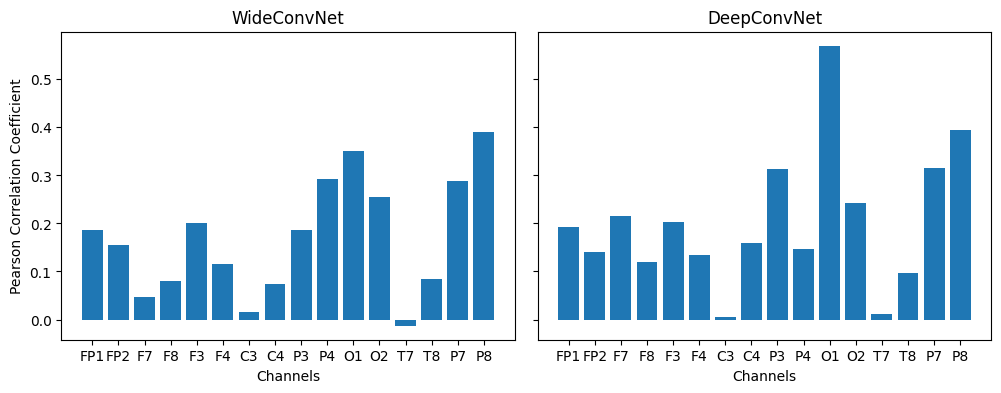

In [ ]:
corr_a_wide= np.zeros((16,1))
corr_a_deep= np.zeros((16,1))
for i in range(16):
  corr_a_wide[i] = np.corrcoef(prob_wide[:,0],ch_shap_wide[:,i,0])[0,1]
  corr_a_deep[i] = np.corrcoef(prob_deep[:,0],ch_shap_deep[:,i,0,0])[0,1]
fig, ax = plt.subplots(1,2,sharey=True,figsize=(12,4))
ax[0].bar(chan,corr_a_wide.reshape(16,));
ax[0].set_ylabel("Pearson Correlation Coefficient");
ax[0].set_title("WideConvNet");
ax[0].set_xlabel("Channels");
ax[1].bar(chan,corr_a_deep.reshape(16,));
ax[1].set_title("DeepConvNet");
ax[1].set_xlabel("Channels");
plt.subplots_adjust(hspace=0.3, wspace=0.05)